<a href="https://colab.research.google.com/github/WuDianQiBian/ml-course/blob/master/notebooks/ch02_python_basics/sec07_numpy_4_answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NumPy 4 思考题

<p align="center">
  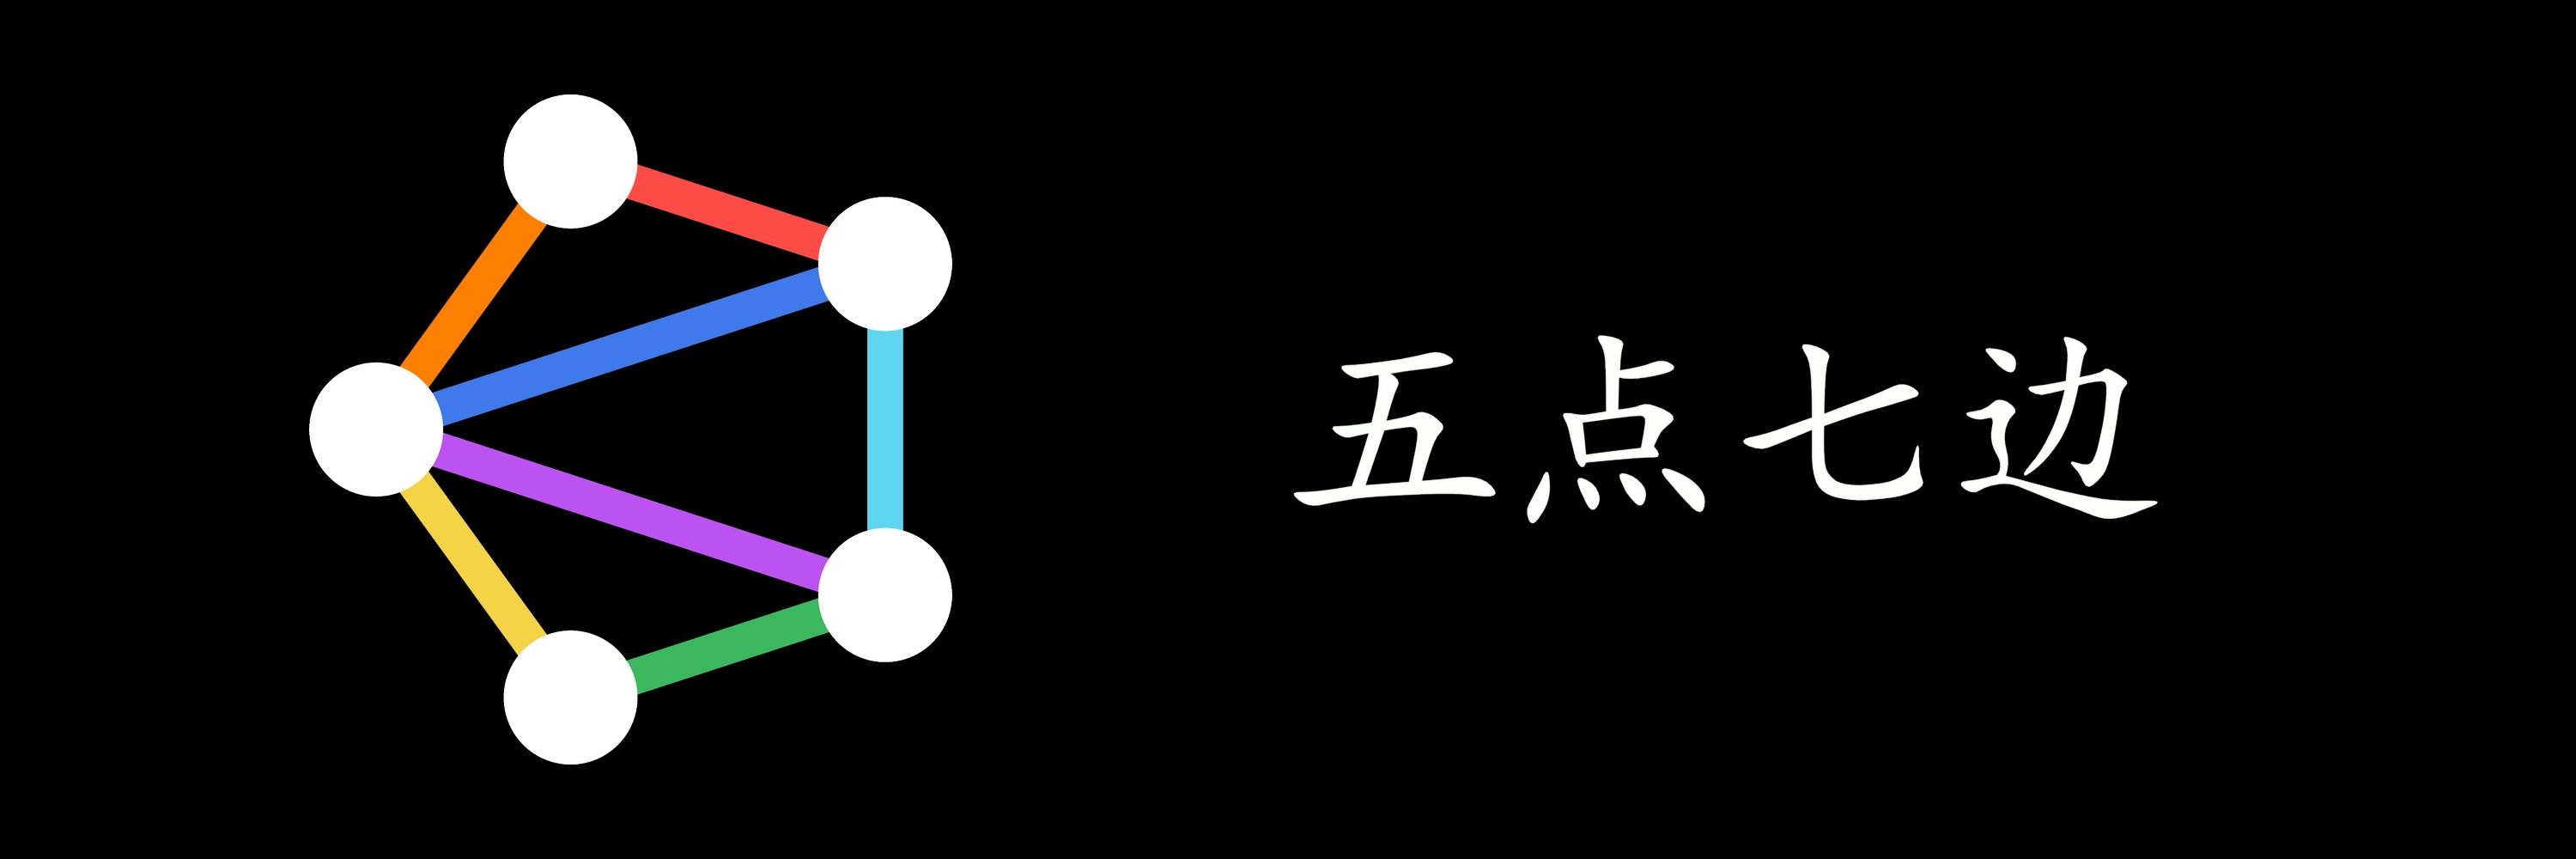
</p>


# 思考题

单位向量的内积，可以用来衡量相似度：

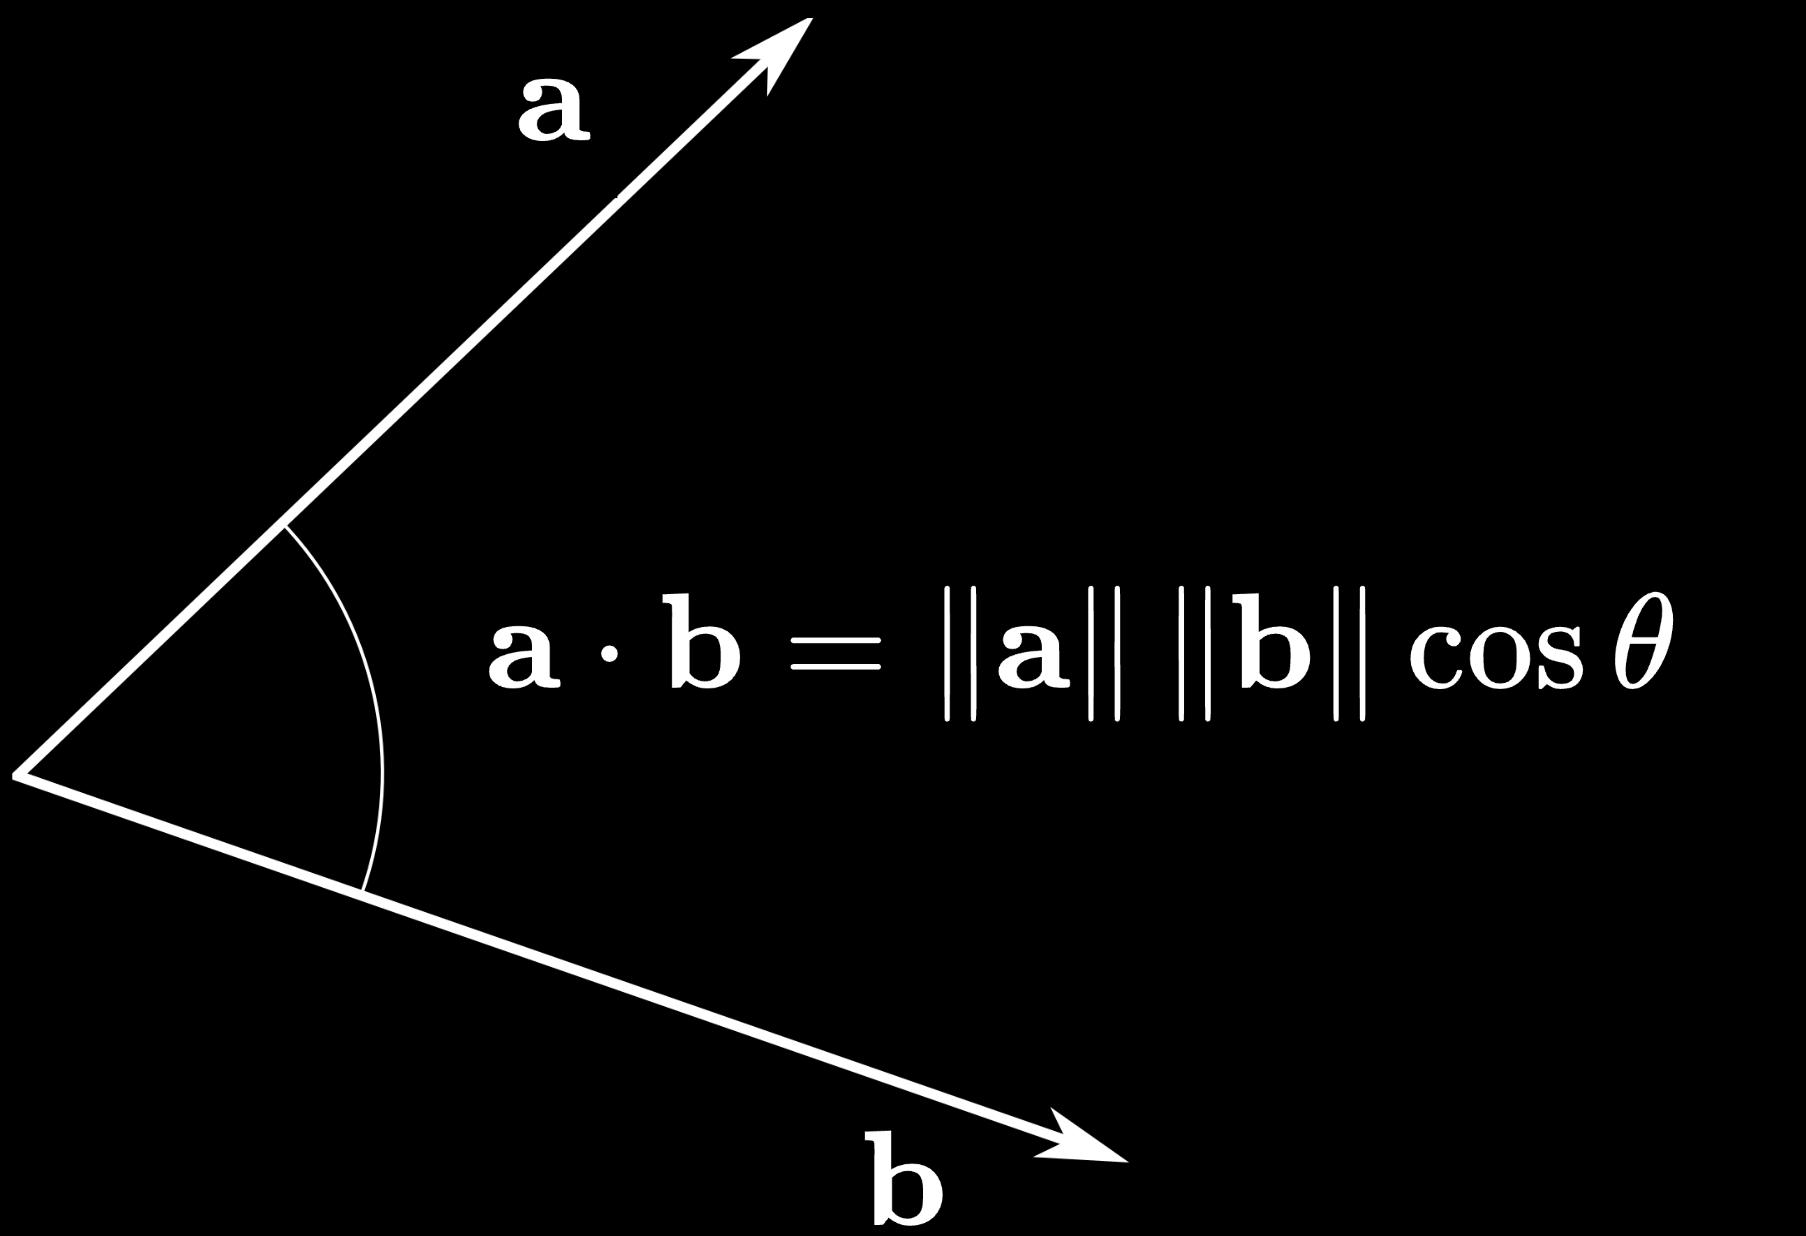

如何给 `N` 个 `D` 维的单位向量，计算彼此间的相似度，画出 `N x N` 的热力图?

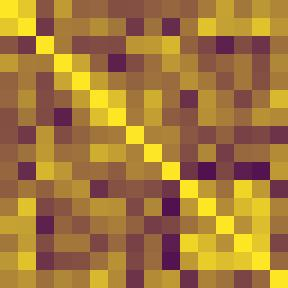


**提示:**
* 是否可以快速计算 N 个向量之间的内积 (点乘) 呢?
* 两个单位向量内积值是否有上下界?
* 先画出每个小块 (某对向量的相似度), 是否会更容易呢?
* 参考下面代码生成单位向量:

# 答案

In [1]:
# @title 辅助函数
import numpy as np
from PIL import Image
from IPython.display import display

def display_image(img):
    display(Image.fromarray(img))

In [2]:
# 生成 N 个 D 维随机向量，并归一化为单位向量
np.random.seed(0)
N, D = 16, 8  # 16 个单位向量，每个单位向量有 8 维
X = np.random.randn(N, D).astype(np.float32)
X = X / np.linalg.norm(X, axis=1, keepdims=True)

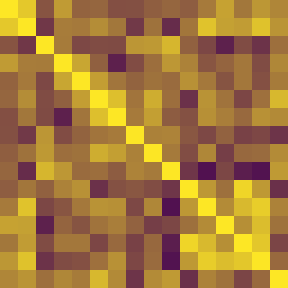

In [3]:
# 计算 N x N 相似度矩阵
sim = X @ X.T  # （N, D) @ (D, N) -> (N, N)
# Note: sim[i, j] 为 X[i] 与 X[j] 的内积

# 用 concatenate + stack 绘制热力图
cell_size = 18
start_color = np.array([68, 1, 84], dtype=np.float32)    # 紫色（低相似度）
end_color   = np.array([253, 231, 37], dtype=np.float32) # 黄色（高相似度）

rows = []
for i in range(N):
    cells = []
    for j in range(N):
        t = (sim[i, j] + 1.0) / 2.0  # 将 [-1, 1] 映射到 [0, 1]
        rgb = start_color * (1.0 - t) + end_color * t

        r = np.full((cell_size, cell_size), rgb[0], dtype=np.uint8)
        g = np.full((cell_size, cell_size), rgb[1], dtype=np.uint8)
        b = np.full((cell_size, cell_size), rgb[2], dtype=np.uint8)

        cell = np.stack([r, g, b], axis=2)  # (cell_size, cell_size, 3)
        cells.append(cell)
    row = np.concatenate(cells, axis=1)
    rows.append(row)

heatmap = np.concatenate(rows, axis=0)
display_image(heatmap)